<a href="https://colab.research.google.com/github/M-Mag25/Group-Work-Project-1-/blob/main/GWP_1_Derivative_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MScFE 620 Derivative Pricing – Group Work Project 1 (Student Group 13544)

COMMON PARAMETERS
S0 = 100.0, K = 100.0, r = 0.05, sigma = 0.2, T = 1.0
Binomial steps: 100, Trinomial steps: 50

STEP 1 – BINOMIAL TREE PRICING

Q5: European ATM options
  Call = $10.43
  Put  = $5.55

Q6: Delta
  Call delta = 0.6365
  Put delta  = -0.3635

Q7: Vega (5% volatility increase)
  Call: $10.43 → $12.31, change = +$1.88
  Put:  $5.55 → $7.43, change = +$1.88

Q8: American ATM options
  Call = $10.43
  Put  = $6.08
  (European put = $5.55, premium = $0.53)

Q9: Delta of American options
  Call delta = 0.6365
  Put delta  = -0.4132

Q10: Vega of American options
  Call: $10.43 → $12.31, change = +$1.88
  Put:  $6.08 → $7.96, change = +$1.88

Q11: Put-call parity (European)
  C - P = 4.8771
  S0 - K e^(-rT) = 4.8771
  Difference = -0.000000

Q12: American put-call inequality
  C - P = 4.3483
  Lower bound = 0.0000, Upper bound = 4.8771
  Within bounds? True

Q13: European vs American call
  European = $10.43, American = $10.43, difference = $0.00

Q14: European vs American put

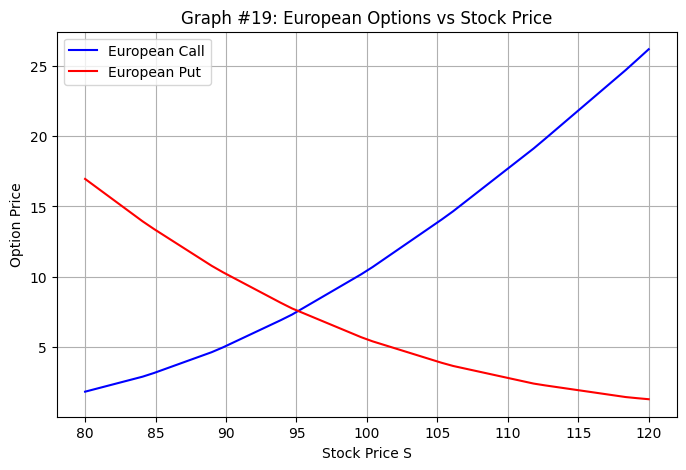

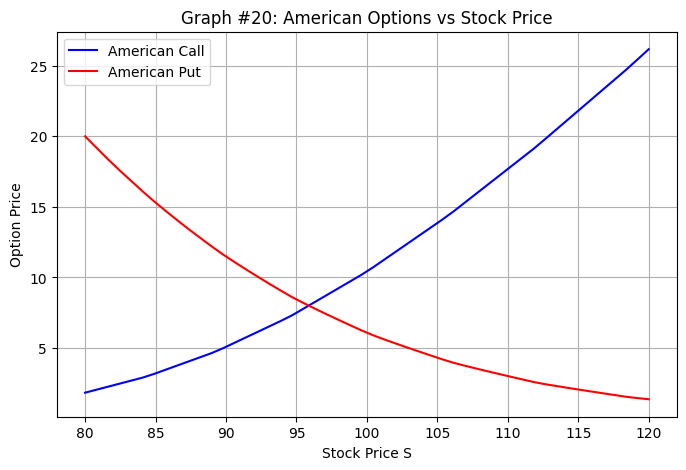

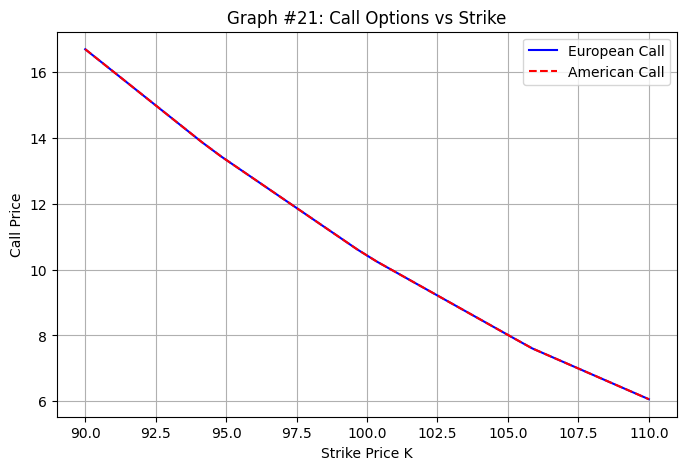

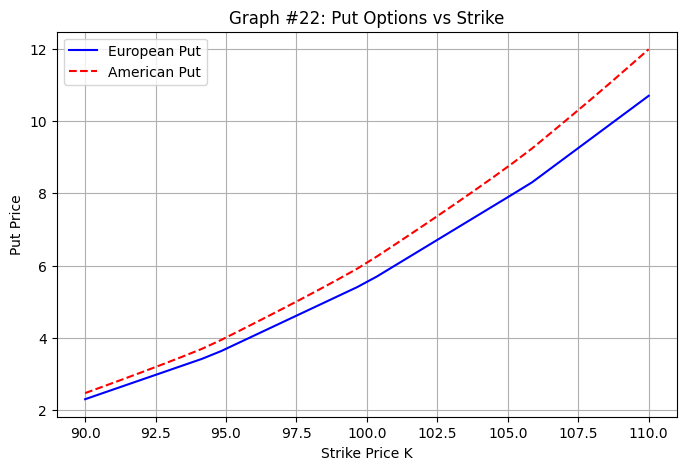


STEP 3 – REAL‑WORLD APPLICATIONS

Q25a: European put price (3‑step) = $13.82

Path: Up, Up, Down
Stock prices: t0=180.00, t1=199.34, t2=180.00, t3=162.54
Deltas: t0=-0.4726, t1=-0.2423, t2=-0.5288

Cash account evolution:
t0: Sell put for 13.82, cash = 13.82
t0: Short 0.4726 shares at 180.00, cash = 98.88, shares = -0.4726
t1: Adjust shares by +0.2302 at 199.34, cash = 52.99, shares = -0.2423
t2: Adjust shares by -0.2865 at 180.00, cash = 104.56, shares = -0.5288
t3: Option expires, stock price 162.54, payoff = 19.46, cash = 85.10
Close shares: cash becomes -0.86
Final cash (hedging error): -0.86

Q26: American put price (25‑step) = $13.04

First 10 stock prices: [180, np.float64(173.75), np.float64(180.0), np.float64(186.48), np.float64(180.0), np.float64(173.75), np.float64(180.0), np.float64(173.75), np.float64(167.71), np.float64(173.75)]
First 10 deltas: [np.float64(-0.4756), np.float64(-0.5608), np.float64(-0.4786), np.float64(-0.3947), np.float64(-0.4819), np.float64(-0.575), n

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)


# Helper Functions (Binomial & Trinomial Trees)

def binomial_european(S, K, T, r, sigma, N, opt_type='call'):
    """European option price using binomial tree."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    asset = np.zeros(N+1)
    for i in range(N+1):
        asset[i] = S * (u ** (N-i)) * (d ** i)

    if opt_type == 'call':
        payoff = np.maximum(asset - K, 0)
    else:
        payoff = np.maximum(K - asset, 0)

    for _ in range(N):
        payoff = disc * (p * payoff[:-1] + (1-p) * payoff[1:])
    return payoff[0]

def binomial_american(S, K, T, r, sigma, N, opt_type='call'):
    """American option price using binomial tree."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    # Asset tree
    asset = np.zeros((N+1, N+1))
    for i in range(N+1):
        for j in range(i+1):
            asset[j, i] = S * (u ** (i-j)) * (d ** j)

    # Value tree
    value = np.zeros((N+1, N+1))
    if opt_type == 'call':
        value[:, N] = np.maximum(asset[:, N] - K, 0)
    else:
        value[:, N] = np.maximum(K - asset[:, N], 0)

    for i in range(N-1, -1, -1):
        for j in range(i+1):
            hold = disc * (p * value[j, i+1] + (1-p) * value[j+1, i+1])
            if opt_type == 'call':
                exercise = max(asset[j, i] - K, 0)
            else:
                exercise = max(K - asset[j, i], 0)
            value[j, i] = max(hold, exercise)
    return value[0, 0]

def trinomial_european(S, K, T, r, sigma, N, opt_type='call'):
    """European option price using trinomial tree (Boyle method)."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(3*dt))
    d = 1 / u
    pu = 1/6 + (r - 0.5*sigma**2) * np.sqrt(dt/(12*sigma**2))
    pd = 1/6 - (r - 0.5*sigma**2) * np.sqrt(dt/(12*sigma**2))
    pm = 2/3
    disc = np.exp(-r * dt)

    # Final asset prices (2N+1 nodes)
    final_asset = np.zeros(2*N+1)
    for i in range(2*N+1):
        final_asset[i] = S * (u ** (N - i))

    if opt_type == 'call':
        final_val = np.maximum(final_asset - K, 0)
    else:
        final_val = np.maximum(K - final_asset, 0)

    for step in range(N-1, -1, -1):
        new_val = np.zeros(2*step+1)
        for i in range(2*step+1):
            new_val[i] = disc * (pu * final_val[i] + pm * final_val[i+1] + pd * final_val[i+2])
        final_val = new_val
    return final_val[0]

def trinomial_american(S, K, T, r, sigma, N, opt_type='call'):
    """American option price using trinomial tree."""
    dt = T / N
    u = np.exp(sigma * np.sqrt(3*dt))
    d = 1 / u
    pu = 1/6 + (r - 0.5*sigma**2) * np.sqrt(dt/(12*sigma**2))
    pd = 1/6 - (r - 0.5*sigma**2) * np.sqrt(dt/(12*sigma**2))
    pm = 2/3
    disc = np.exp(-r * dt)

    # Store asset prices in dictionary
    asset = {}
    for i in range(N+1):
        for j in range(-i, i+1):
            asset[(i, j)] = S * (u ** j)

    # Value at maturity
    val = {}
    for j in range(-N, N+1):
        if opt_type == 'call':
            val[(N, j)] = max(asset[(N, j)] - K, 0)
        else:
            val[(N, j)] = max(K - asset[(N, j)], 0)

    # Backward induction
    for i in range(N-1, -1, -1):
        for j in range(-i, i+1):
            hold = disc * (pu * val[(i+1, j+1)] + pm * val[(i+1, j)] + pd * val[(i+1, j-1)])
            if opt_type == 'call':
                exercise = max(asset[(i, j)] - K, 0)
            else:
                exercise = max(K - asset[(i, j)], 0)
            val[(i, j)] = max(hold, exercise)
    return val[(0, 0)]

def delta_european(S, K, T, r, sigma, N, opt_type):
    """Delta of European option by finite difference."""
    eps = 0.01 * S
    V_up = binomial_european(S+eps, K, T, r, sigma, N, opt_type)
    V_down = binomial_european(S-eps, K, T, r, sigma, N, opt_type)
    return (V_up - V_down) / (2*eps)

def delta_american(S, K, T, r, sigma, N, opt_type):
    """Delta of American option by finite difference."""
    eps = 0.01 * S
    V_up = binomial_american(S+eps, K, T, r, sigma, N, opt_type)
    V_down = binomial_american(S-eps, K, T, r, sigma, N, opt_type)
    return (V_up - V_down) / (2*eps)


# Common Parameters (Step 1 & 2)

S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.20
T = 1.0
N_bin = 100      # binomial steps
N_tri = 50       # trinomial steps

print("="*70)
print("COMMON PARAMETERS")
print("="*70)
print(f"S0 = {S0}, K = {K}, r = {r}, sigma = {sigma}, T = {T}")
print(f"Binomial steps: {N_bin}, Trinomial steps: {N_tri}\n")


# STEP 1 – Binomial Tree Pricing (Team Member A)


print("="*70)
print("STEP 1 – BINOMIAL TREE PRICING")
print("="*70)

# Q5: European ATM options
call_eu = binomial_european(S0, K, T, r, sigma, N_bin, 'call')
put_eu  = binomial_european(S0, K, T, r, sigma, N_bin, 'put')
print("\nQ5: European ATM options")
print(f"  Call = ${call_eu:.2f}")
print(f"  Put  = ${put_eu:.2f}")

# Q6: Delta
delta_c_eu = delta_european(S0, K, T, r, sigma, N_bin, 'call')
delta_p_eu = delta_european(S0, K, T, r, sigma, N_bin, 'put')
print("\nQ6: Delta")
print(f"  Call delta = {delta_c_eu:.4f}")
print(f"  Put delta  = {delta_p_eu:.4f}")

# Q7: Vega (5% volatility increase)
sigma2 = 0.25
call_eu2 = binomial_european(S0, K, T, r, sigma2, N_bin, 'call')
put_eu2  = binomial_european(S0, K, T, r, sigma2, N_bin, 'put')
print("\nQ7: Vega (5% volatility increase)")
print(f"  Call: ${call_eu:.2f} → ${call_eu2:.2f}, change = +${call_eu2-call_eu:.2f}")
print(f"  Put:  ${put_eu:.2f} → ${put_eu2:.2f}, change = +${put_eu2-put_eu:.2f}")

# Q8: American ATM options
call_am = binomial_american(S0, K, T, r, sigma, N_bin, 'call')
put_am  = binomial_american(S0, K, T, r, sigma, N_bin, 'put')
print("\nQ8: American ATM options")
print(f"  Call = ${call_am:.2f}")
print(f"  Put  = ${put_am:.2f}")
print(f"  (European put = ${put_eu:.2f}, premium = ${put_am-put_eu:.2f})")

# Q9: Delta of American options
delta_c_am = delta_american(S0, K, T, r, sigma, N_bin, 'call')
delta_p_am = delta_american(S0, K, T, r, sigma, N_bin, 'put')
print("\nQ9: Delta of American options")
print(f"  Call delta = {delta_c_am:.4f}")
print(f"  Put delta  = {delta_p_am:.4f}")

# Q10: Vega of American options
call_am2 = binomial_american(S0, K, T, r, sigma2, N_bin, 'call')
put_am2  = binomial_american(S0, K, T, r, sigma2, N_bin, 'put')
print("\nQ10: Vega of American options")
print(f"  Call: ${call_am:.2f} → ${call_am2:.2f}, change = +${call_am2-call_am:.2f}")
print(f"  Put:  ${put_am:.2f} → ${put_am2:.2f}, change = +${put_am2-put_am:.2f}")

# Q11: European put-call parity
pcp_left = call_eu - put_eu
pcp_right = S0 - K * np.exp(-r * T)
print("\nQ11: Put-call parity (European)")
print(f"  C - P = {pcp_left:.4f}")
print(f"  S0 - K e^(-rT) = {pcp_right:.4f}")
print(f"  Difference = {pcp_left - pcp_right:.6f}")

# Q12: American put-call inequality
pcp_am = call_am - put_am
lower = S0 - K
upper = pcp_right
print("\nQ12: American put-call inequality")
print(f"  C - P = {pcp_am:.4f}")
print(f"  Lower bound = {lower:.4f}, Upper bound = {upper:.4f}")
print(f"  Within bounds? {lower <= pcp_am <= upper}")

# Q13: European vs American call
print("\nQ13: European vs American call")
print(f"  European = ${call_eu:.2f}, American = ${call_am:.2f}, difference = ${call_am-call_eu:.2f}")

# Q14: European vs American put
print("\nQ14: European vs American put")
print(f"  European = ${put_eu:.2f}, American = ${put_am:.2f}, difference = ${put_am-put_eu:.2f}")


# STEP 2 – Trinomial Tree Pricing (Team Member A)

print("\n" + "="*70)
print("STEP 2 – TRINOMIAL TREE PRICING")
print("="*70)

strikes = [90, 95, 100, 105, 110]

# Q15: European call (trinomial)
call_tri_eu = [trinomial_european(S0, K, T, r, sigma, N_tri, 'call') for K in strikes]
print("\nQ15: European call prices (trinomial)")
for k, p in zip(strikes, call_tri_eu):
    print(f"  K={k}: ${p:.2f}")

# Q16: European put (trinomial)
put_tri_eu = [trinomial_european(S0, K, T, r, sigma, N_tri, 'put') for K in strikes]
print("\nQ16: European put prices (trinomial)")
for k, p in zip(strikes, put_tri_eu):
    print(f"  K={k}: ${p:.2f}")

# Q17: American call (trinomial)
call_tri_am = [trinomial_american(S0, K, T, r, sigma, N_tri, 'call') for K in strikes]
print("\nQ17: American call prices (trinomial)")
for k, p in zip(strikes, call_tri_am):
    print(f"  K={k}: ${p:.2f}")

# Q18: American put (trinomial)
put_tri_am = [trinomial_american(S0, K, T, r, sigma, N_tri, 'put') for K in strikes]
print("\nQ18: American put prices (trinomial)")
for k, p in zip(strikes, put_tri_am):
    print(f"  K={k}: ${p:.2f}")

# Q23: European put-call parity for the five strikes
print("\nQ23: European put-call parity (trinomial)")
print("K    C       P       C-P     S0-Ke^{-rT}  Diff")
for i, k in enumerate(strikes):
    lhs = call_tri_eu[i] - put_tri_eu[i]
    rhs = S0 - k * np.exp(-r * T)
    diff = lhs - rhs
    print(f"{k:3d} {call_tri_eu[i]:6.2f} {put_tri_eu[i]:6.2f} {lhs:6.2f} {rhs:6.2f} {diff:6.2f}")

# Q24: American put-call inequality check
print("\nQ24: American put-call inequality")
print("K    C       P       C-P     Lower   Upper   Within?")
for i, k in enumerate(strikes):
    lhs = call_tri_am[i] - put_tri_am[i]
    lower = S0 - k
    upper = S0 - k * np.exp(-r * T)
    within = lower <= lhs <= upper
    print(f"{k:3d} {call_tri_am[i]:6.2f} {put_tri_am[i]:6.2f} {lhs:6.2f} {lower:6.2f} {upper:6.2f} {within}")


print("\n" + "="*70)
print("GENERATING GRAPHS (Q19–Q22)")
print("="*70)

# Use fewer steps for speed, but still accurate
N_graph = 50
S_range = np.linspace(80, 120, 50)
K_range = np.linspace(90, 110, 30)

# Q19
call_eu_S = [binomial_european(S, K, T, r, sigma, N_graph, 'call') for S in S_range]
put_eu_S  = [binomial_european(S, K, T, r, sigma, N_graph, 'put') for S in S_range]

plt.figure(figsize=(8,5))
plt.plot(S_range, call_eu_S, 'b-', label='European Call')
plt.plot(S_range, put_eu_S, 'r-', label='European Put')
plt.xlabel('Stock Price S')
plt.ylabel('Option Price')
plt.title('Graph #19: European Options vs Stock Price')
plt.legend()
plt.grid(True)
plt.savefig('Q19_european_vs_stock.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Q20
call_am_S = [binomial_american(S, K, T, r, sigma, N_graph, 'call') for S in S_range]
put_am_S  = [binomial_american(S, K, T, r, sigma, N_graph, 'put') for S in S_range]

plt.figure(figsize=(8,5))
plt.plot(S_range, call_am_S, 'b-', label='American Call')
plt.plot(S_range, put_am_S, 'r-', label='American Put')
plt.xlabel('Stock Price S')
plt.ylabel('Option Price')
plt.title('Graph #20: American Options vs Stock Price')
plt.legend()
plt.grid(True)
plt.savefig('Q20_american_vs_stock.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Q21
call_eu_K = [binomial_european(S0, K, T, r, sigma, N_graph, 'call') for K in K_range]
call_am_K = [binomial_american(S0, K, T, r, sigma, N_graph, 'call') for K in K_range]

plt.figure(figsize=(8,5))
plt.plot(K_range, call_eu_K, 'b-', label='European Call')
plt.plot(K_range, call_am_K, 'r--', label='American Call')
plt.xlabel('Strike Price K')
plt.ylabel('Call Price')
plt.title('Graph #21: Call Options vs Strike')
plt.legend()
plt.grid(True)
plt.savefig('Q21_calls_vs_strike.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Q22
put_eu_K = [binomial_european(S0, K, T, r, sigma, N_graph, 'put') for K in K_range]
put_am_K = [binomial_american(S0, K, T, r, sigma, N_graph, 'put') for K in K_range]

plt.figure(figsize=(8,5))
plt.plot(K_range, put_eu_K, 'b-', label='European Put')
plt.plot(K_range, put_am_K, 'r--', label='American Put')
plt.xlabel('Strike Price K')
plt.ylabel('Put Price')
plt.title('Graph #22: Put Options vs Strike')
plt.legend()
plt.grid(True)
plt.savefig('Q22_puts_vs_strike.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()



# STEP 3 – Real‑World Applications (Q25–Q27)

print("\n" + "="*70)
print("STEP 3 – REAL‑WORLD APPLICATIONS")
print("="*70)

# Parameters for Q25-27
S0_h = 180
K_h = 182
r_h = 0.02
sigma_h = 0.25
T_h = 0.5

# Q25: 3‑step binomial tree for European put

N3 = 3
dt = T_h / N3
u = np.exp(sigma_h * np.sqrt(dt))
d = 1 / u
p = (np.exp(r_h * dt) - d) / (u - d)
disc = np.exp(-r_h * dt)

# Asset tree
S3 = np.zeros((N3+1, N3+1))
for i in range(N3+1):
    for j in range(i+1):
        S3[j, i] = S0_h * (u ** (i-j)) * (d ** j)

# European put values
V3 = np.zeros((N3+1, N3+1))
V3[:, N3] = np.maximum(K_h - S3[:, N3], 0)
for i in range(N3-1, -1, -1):
    for j in range(i+1):
        V3[j, i] = disc * (p * V3[j, i+1] + (1-p) * V3[j+1, i+1])

put_price_25 = V3[0, 0]
print(f"\nQ25a: European put price (3‑step) = ${put_price_25:.2f}")

# Deltas
Delta3 = np.zeros((N3, N3))
for i in range(N3):
    for j in range(i+1):
        Delta3[j, i] = (V3[j, i+1] - V3[j+1, i+1]) / (S3[j, i+1] - S3[j+1, i+1])

# Choose a path: Up, Up, Down
path = [0,0,1,2]  # indices of nodes: (0,0) -> (0,1) -> (1,2) -> (2,3)
S_path = [S3[0,0], S3[0,1], S3[1,2], S3[2,3]]
delta_path = [Delta3[0,0], Delta3[0,1], Delta3[1,2]]

print("\nPath: Up, Up, Down")
print(f"Stock prices: t0={S_path[0]:.2f}, t1={S_path[1]:.2f}, t2={S_path[2]:.2f}, t3={S_path[3]:.2f}")
print(f"Deltas: t0={delta_path[0]:.4f}, t1={delta_path[1]:.4f}, t2={delta_path[2]:.4f}")

# Hedging simulation (seller of put)
cash = V3[0,0]
shares = 0
print("\nCash account evolution:")
print(f"t0: Sell put for {cash:.2f}, cash = {cash:.2f}")
shares = delta_path[0]
cash += -delta_path[0] * S_path[0]
print(f"t0: Short {-delta_path[0]:.4f} shares at {S_path[0]:.2f}, cash = {cash:.2f}, shares = {shares:.4f}")

# t1
delta_shares = delta_path[1] - shares
cash -= delta_shares * S_path[1]
shares = delta_path[1]
print(f"t1: Adjust shares by {delta_shares:+.4f} at {S_path[1]:.2f}, cash = {cash:.2f}, shares = {shares:.4f}")

# t2
delta_shares = delta_path[2] - shares
cash -= delta_shares * S_path[2]
shares = delta_path[2]
print(f"t2: Adjust shares by {delta_shares:+.4f} at {S_path[2]:.2f}, cash = {cash:.2f}, shares = {shares:.4f}")

# t3: expiration
payoff = max(K_h - S_path[3], 0)
cash -= payoff
print(f"t3: Option expires, stock price {S_path[3]:.2f}, payoff = {payoff:.2f}, cash = {cash:.2f}")
if abs(shares) > 1e-6:
    cash += shares * S_path[3]
    print(f"Close shares: cash becomes {cash:.2f}")
print(f"Final cash (hedging error): {cash:.2f}")


# Q26: American put – 25‑step tree and hedging
def american_put_tree(S0, K, T, r, sigma, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    S = np.zeros((N+1, N+1))
    for i in range(N+1):
        for j in range(i+1):
            S[j, i] = S0 * (u ** (i-j)) * (d ** j)

    V = np.zeros((N+1, N+1))
    V[:, N] = np.maximum(K - S[:, N], 0)
    Delta = np.zeros((N, N))

    for i in range(N-1, -1, -1):
        for j in range(i+1):
            hold = disc * (p * V[j, i+1] + (1-p) * V[j+1, i+1])
            exercise = max(K - S[j, i], 0)
            V[j, i] = max(hold, exercise)
            S_up = S[j, i+1]
            S_down = S[j+1, i+1]
            V_up = V[j, i+1]
            V_down = V[j+1, i+1]
            Delta[j, i] = (V_up - V_down) / (S_up - S_down)
    return S, V, Delta

N_h = 25
S_tree, V_tree, Delta_tree = american_put_tree(S0_h, K_h, T_h, r_h, sigma_h, N_h)
put_am_price = V_tree[0,0]
print(f"\nQ26: American put price (25‑step) = ${put_am_price:.2f}")

# Simulate a random path
np.random.seed(123)
dt = T_h / N_h
u = np.exp(sigma_h * np.sqrt(dt))
d = 1/u
p = (np.exp(r_h * dt) - d) / (u - d)
path = np.random.choice(['u','d'], size=N_h, p=[p, 1-p])

S_path26 = [S0_h]
j = 0
for move in path:
    if move == 'u':
        j = j
    else:
        j = j + 1
    S_path26.append(S_tree[j, len(S_path26)])

deltas_path26 = []
j = 0
for i in range(N_h):
    deltas_path26.append(Delta_tree[j, i])
    if path[i] == 'u':
        j = j
    else:
        j = j + 1

print("\nFirst 10 stock prices:", [round(s,2) for s in S_path26[:10]])
print("First 10 deltas:", [round(d,4) for d in deltas_path26[:10]])

# Hedging simulation (seller of put)
cash = V_tree[0,0]
shares = 0
print("\nCash account evolution (first few steps):")
print(f"t0: Sell put for {cash:.2f}, cash = {cash:.2f}")
shares = deltas_path26[0]
cash += -shares * S_path26[0]   # shares negative, so -shares positive
print(f"t0: Short {-shares:.4f} shares at {S_path26[0]:.2f}, cash = {cash:.2f}, shares = {shares:.4f}")

for i in range(1, N_h):
    new_shares = deltas_path26[i]
    delta_shares = new_shares - shares
    cash -= delta_shares * S_path26[i]
    shares = new_shares
    if i < 5:
        print(f"t{i}: Adjust shares by {delta_shares:+.4f} at {S_path26[i]:.2f}, cash = {cash:.2f}, shares = {shares:.4f}")

# Maturity
payoff = max(K_h - S_path26[N_h], 0)
cash -= payoff
print(f"t{N_h}: Option expires, stock price {S_path26[N_h]:.2f}, payoff = {payoff:.2f}, cash = {cash:.2f}")
if abs(shares) > 1e-6:
    cash += shares * S_path26[N_h]
    print(f"Close shares: cash becomes {cash:.2f}")
print(f"Final cash (hedging error): {cash:.2f}")


# Q27: Asian ATM put option (Monte Carlo)

def asian_put_mc(S0, K, T, r, sigma, N_steps, N_paths=100000):
    dt = T / N_steps
    nudt = (r - 0.5*sigma**2) * dt
    sigsqrtdt = sigma * np.sqrt(dt)
    discount = np.exp(-r * T)
    sum_payoff = 0
    for _ in range(N_paths):
        S = S0
        path_sum = S
        for _ in range(N_steps):
            epsilon = np.random.normal()
            S = S * np.exp(nudt + sigsqrtdt * epsilon)
            path_sum += S
        avg = path_sum / (N_steps + 1)
        payoff = max(K - avg, 0)
        sum_payoff += payoff
    return discount * sum_payoff / N_paths

np.random.seed(123)
asian_price = asian_put_mc(S0_h, K_h, T_h, r_h, sigma_h, 25, 100000)
print(f"\nQ27: Asian ATM put price (MC) = ${asian_price:.2f}")
print(f"American put price (from Q26) = ${put_am_price:.2f}")
print(f"European put price (from Q25) = ${put_price_25:.2f}")

print("\n" + "="*70)
print("="*70)